In [1]:
from synaptic_tomo_tools.activezone import (
    import_membrane_segmentations_from_glb, 
    find_active_zones_from_glb, 
    define_active_zonogram, 
    extract_active_zonogram, 
    transform_coordinates_to_active_zonogram
)
from matplotlib import pyplot as plt
import numpy as np
from pathlib import Path
import starfile


In [2]:
tomo_path = "/nrs/elferich/20241030_AMmilled12-1_15"

In [3]:
membranes_glb = import_membrane_segmentations_from_glb(tomo_path)
active_zones_glb = find_active_zones_from_glb(membranes_glb)

Found active zone: active_zone_pre1_post1 with 111280 presynaptic and 101361 postsynaptic points


In [4]:
active_zonograms = define_active_zonogram(active_zones_glb)

Defining active zonogram


In [5]:
active_zonograms

{'status': 'completed',
 'active_zone_count': 1,
 'zonogram_data': {'active_zone_pre1_post1': {'center': array([369.14154937, 561.88627292, 149.26047545]),
   'transformation_matrix': array([[ 6.7456633e-01, -7.3821419e-01,  0.0000000e+00,  1.6578200e+02],
          [ 3.5457417e-01,  3.2400325e-01, -8.7709695e-01, -1.8202513e+02],
          [ 6.4748544e-01,  5.9166008e-01,  4.8031339e-01, -6.4315125e+02],
          [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e+00]],
         dtype=float32),
   'extent': array([576, 188,  86])}}}

In [6]:
transformed_tomo = extract_active_zonogram(active_zonograms=active_zonograms, active_zones=active_zones_glb, tomo_path=tomo_path,tomo_type='BIN4')

Rendering active zonogram


In [7]:
aunps_dir = Path(tomo_path) / "best_alignment" / "aunps"
star_file = aunps_dir / f"aunp_tm_BP.star"
star_data = starfile.read(star_file)
star_data = star_data[star_data['faTM_PeakScore'] > 0.38]
coordinates = star_data[['faTM_PeakX', 'faTM_PeakY', 'faTM_PeakZ']].values + star_data[['faTomo_gaussianFitX', 'faTomo_gaussianFitY', 'faTomo_gaussianFitZ']].values
az_coordinates = transform_coordinates_to_active_zonogram(coordinates, active_zonograms['zonogram_data']['active_zone_pre1_post1'])

/tmp/ipykernel_2504408/433853229.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


(0.0, 188.0)

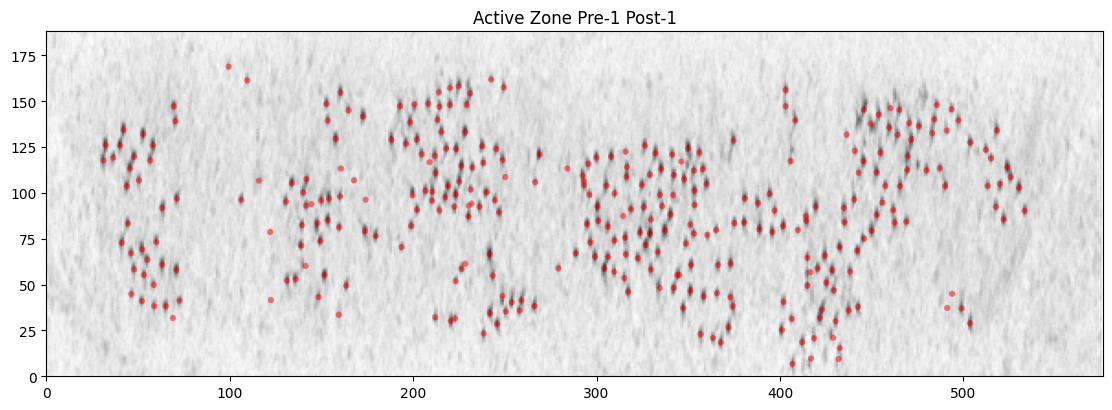

In [ ]:
plt.figure(figsize=(30, 10))
plt.subplot(1, 2, 1)
plt.title('Active Zone Pre-1 Post-1')
plt.imshow(np.min(transformed_tomo['rendered_zonograms']['active_zone_pre1_post1']['transformed_tomogram'], axis=0), cmap='gray',origin='lower')
plt.scatter(
    az_coordinates[:, 0],
    az_coordinates[:, 1],
    c="red", # color by integral
    s=20,                # circle size
    edgecolors='none',       # red edge
    alpha=0.5,             # transparency
)
plt.xlim(0, transformed_tomo['rendered_zonograms']['active_zone_pre1_post1']['transformed_tomogram'].shape[2])
plt.ylim(0, transformed_tomo['rendered_zonograms']['active_zone_pre1_post1']['transformed_tomogram'].shape[1])
